# Prétraitement

1. Affichage des N premières lignes

In [2]:
def get_first_n_lines(path: str, lines: int) -> list[str]:
    with open(path, "r") as f:
        head = [next(f) for _ in range(lines)]
    return head

print("TR :")
print("".join(get_first_n_lines("./Training_BOP.csv", 5)))
print("TS :")
print("".join(get_first_n_lines("./Testing_BOP.csv", 5)))

TR :
sku,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,sales_9_month,min_bank,potential_issue,pieces_past_due,perf_6_month_avg,perf_12_month_avg,local_bo_qty,deck_risk,oe_constraint,ppap_risk,stop_auto_buy,rev_stop,went_on_backorder
1026827,0,,0,0,0,0,0,0,0,0,0,No,0,-99,-99,0,No,No,No,Yes,No,No
1043384,2,9,0,0,0,0,0,0,0,0,0,No,0,0.990,0.990,0,No,No,No,Yes,No,No
1043696,2,,0,0,0,0,0,0,0,0,0,No,0,-99,-99,0,Yes,No,No,Yes,No,No
1043852,7,8,0,0,0,0,0,0,0,0,1,No,0,0.100,0.130,0,No,No,No,Yes,No,No

TS :
sku,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,sales_9_month,min_bank,potential_issue,pieces_past_due,perf_6_month_avg,perf_12_month_avg,local_bo_qty,deck_risk,oe_constraint,ppap_risk,stop_auto_buy,rev_stop,went_on_backorder
3285085,62,,0,0,0,0,0,0,0,0,1,No,0,-99,-99,0,Yes,No,No,Yes,No,No
3285131,9,,0,0,0,0,0,0,0,0,1,No,0,-

2. Dimensions de TR et TS

In [3]:
def get_dimensions(path: str) -> int:
    first_line = get_first_n_lines(path, 1)[0]
    return len(first_line.split(","))

print("Dimensions")
print(f'TR -> {get_dimensions("./Training_BOP.csv")}')
print(f'TS -> {get_dimensions("./Testing_BOP.csv")}')

Dimensions
TR -> 23
TS -> 23


3. Types de variables

In [ ]:
# Importation du module pandas
import pandas as pd
from typing import Any

In [ ]:
# Creation des dataframes TR et TS
trdf = pd.read_csv("Training_BOP.csv")
tsdf = pd.read_csv("Testing_BOP.csv")

/tmp/ipykernel_17059/2017721217.py:1: DtypeWarning: Columns (0: sku) have mixed types. Specify dtype option on import or set low_memory=False.
  trdf = pd.read_csv("Training_BOP.csv")
/tmp/ipykernel_17059/2017721217.py:2: DtypeWarning: Columns (0: sku) have mixed types. Specify dtype option on import or set low_memory=False.
  tsdf = pd.read_csv("Testing_BOP.csv")


In [ ]:
# Affichage des types de données des colonnes de TR
print("TR: ")
print(trdf.dtypes)

TR: 
sku                   object
national_inv         float64
lead_time            float64
in_transit_qty       float64
forecast_3_month     float64
forecast_6_month     float64
forecast_9_month     float64
sales_1_month        float64
sales_3_month        float64
sales_6_month        float64
sales_9_month        float64
min_bank             float64
potential_issue          str
pieces_past_due      float64
perf_6_month_avg     float64
perf_12_month_avg    float64
local_bo_qty         float64
deck_risk                str
oe_constraint            str
ppap_risk                str
stop_auto_buy            str
rev_stop                 str
went_on_backorder        str
dtype: object
TS: 
sku                   object
national_inv         float64
lead_time            float64
in_transit_qty       float64
forecast_3_month     float64
forecast_6_month     float64
forecast_9_month     float64
sales_1_month        float64
sales_3_month        float64
sales_6_month        float64
sales_9_month      

In [ ]:
# Affichage des types de données des colonnes de TS
print("TS: ")
print(tsdf.dtypes)

TS: 
sku                   object
national_inv         float64
lead_time            float64
in_transit_qty       float64
forecast_3_month     float64
forecast_6_month     float64
forecast_9_month     float64
sales_1_month        float64
sales_3_month        float64
sales_6_month        float64
sales_9_month        float64
min_bank             float64
potential_issue          str
pieces_past_due      float64
perf_6_month_avg     float64
perf_12_month_avg    float64
local_bo_qty         float64
deck_risk                str
oe_constraint            str
ppap_risk                str
stop_auto_buy            str
rev_stop                 str
went_on_backorder        str
dtype: object


4. Extraction des valeurs manquantes

In [19]:
def get_missing_values(df: pd.DataFrame) -> Any:
    return df.isna().sum()

def get_missing_percentage(df: pd.DataFrame) -> Any:
    return (df.isna().sum() / len(df)) * 100

In [22]:
print(f"TR - Missing values percentage: \n{get_missing_percentage(trdf)}")
print(f"TR - Missing values: \n{get_missing_values(trdf)}")

TR - Missing values percentage: 
sku                  0.000000
national_inv         0.000059
lead_time            5.977625
in_transit_qty       0.000059
forecast_3_month     0.000059
forecast_6_month     0.000059
forecast_9_month     0.000059
sales_1_month        0.000059
sales_3_month        0.000059
sales_6_month        0.000059
sales_9_month        0.000059
min_bank             0.000059
potential_issue      0.000059
pieces_past_due      0.000059
perf_6_month_avg     0.000059
perf_12_month_avg    0.000059
local_bo_qty         0.000059
deck_risk            0.000059
oe_constraint        0.000059
ppap_risk            0.000059
stop_auto_buy        0.000059
rev_stop             0.000059
went_on_backorder    0.000059
dtype: float64
TR - Missing values: 
sku                       0
national_inv              1
lead_time            100894
in_transit_qty            1
forecast_3_month          1
forecast_6_month          1
forecast_9_month          1
sales_1_month             1
sales_3_month   

In [23]:
print(f"TS - Missing values percentage: \n{get_missing_percentage(tsdf)}")
print(f"TS - Missing values: \n{get_missing_values(tsdf)}")

TS - Missing values percentage: 
sku                  0.000000
national_inv         0.000413
lead_time            6.082800
in_transit_qty       0.000413
forecast_3_month     0.000413
forecast_6_month     0.000413
forecast_9_month     0.000413
sales_1_month        0.000413
sales_3_month        0.000413
sales_6_month        0.000413
sales_9_month        0.000413
min_bank             0.000413
potential_issue      0.000413
pieces_past_due      0.000413
perf_6_month_avg     0.000413
perf_12_month_avg    0.000413
local_bo_qty         0.000413
deck_risk            0.000413
oe_constraint        0.000413
ppap_risk            0.000413
stop_auto_buy        0.000413
rev_stop             0.000413
went_on_backorder    0.000413
dtype: float64
TS - Missing values: 
sku                      0
national_inv             1
lead_time            14725
in_transit_qty           1
forecast_3_month         1
forecast_6_month         1
forecast_9_month         1
sales_1_month            1
sales_3_month           

5. Tableau statistique

In [10]:
trdf.describe()

,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,sales_9_month,min_bank,pieces_past_due,perf_6_month_avg,perf_12_month_avg,local_bo_qty
count,1.687860e+06,1.586967e+06,1.687860e+06,1.687860e+06,1.687860e+06,1.687860e+06,1.687860e+06,1.687860e+06,1.687860e+06,1.687860e+06,1.687860e+06,1.687860e+06,1.687860e+06,1.687860e+06,1.687860e+06
mean,4.961118e+02,7.872267e+00,4.405202e+01,1.781193e+02,3.449867e+02,5.063644e+02,5.592607e+01,1.750259e+02,3.417288e+02,5.252697e+02,5.277230e+01,2.043724e+00,-6.872059e+00,-6.437947e+00,6.264507e-01
std,2.961523e+04,7.056024e+00,1.342742e+03,5.026553e+03,9.795152e+03,1.437892e+04,1.928196e+03,5.192378e+03,9.613167e+03,1.483861e+04,1.254983e+03,2.360165e+02,2.655636e+01,2.584333e+01,3.372224e+01
min,-2.725600e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-9.900000e+01,-9.900000e+01,0.000000e+00
25%,4.000000e+00,4.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.300000e-01,6.600000e-01,0.000000e+00
50%,1.500000e+01,8.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,2.000000e+00,4.000000e+00,0.000000e+00,0.000000e+00,8.200000e-01,8.100000e-01,0.000000e+00
75%,8.000000e+01,9.000000e+00,0.000000e+00,4.000000e+00,1.200000e+01,2.000000e+01,4.000000e+00,1.500000e+01,3.100000e+01,4.700000e+01,3.000000e+00,0.000000e+00,9.700000e-01,9.500000e-01,0.000000e+00
max,1.233440e+07,5.200000e+01,4.894080e+05,1.427612e+06,2.461360e+06,3.777304e+06,7.417740e+05,1.105478e+06,2.146625e+06,3.205172e+06,3.133190e+05,1.464960e+05,1.000000e+00,1.000000e+00,1.253000e+04


In [11]:
tsdf.describe()

,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,sales_9_month,min_bank,pieces_past_due,perf_6_month_avg,perf_12_month_avg,local_bo_qty
count,2.420750e+05,227351.000000,242075.000000,2.420750e+05,2.420750e+05,2.420750e+05,242075.000000,2.420750e+05,2.420750e+05,2.420750e+05,242075.000000,242075.000000,242075.000000,242075.000000,242075.000000
mean,4.997510e+02,7.923018,36.178213,1.814723e+02,3.488073e+02,5.082963e+02,51.478195,1.721393e+02,3.404254e+02,5.117754e+02,52.804693,1.824236,-7.093779,-6.632445,0.843726
std,2.928039e+04,7.041410,898.673127,5.648875e+03,1.008180e+04,1.410972e+04,1544.678350,5.164244e+03,9.386523e+03,1.397670e+04,1278.591177,178.679263,26.900636,26.160720,45.606626
min,-2.541400e+04,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,-99.000000,-99.000000,0.000000
25%,4.000000e+00,4.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.630000,0.660000,0.000000
50%,1.500000e+01,8.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,1.000000e+00,2.000000e+00,4.000000e+00,0.000000,0.000000,0.820000,0.810000,0.000000
75%,8.100000e+01,9.000000,0.000000,4.000000e+00,1.200000e+01,2.000000e+01,4.000000,1.400000e+01,3.000000e+01,4.600000e+01,3.000000,0.000000,0.960000,0.950000,0.000000
max,1.214579e+07,52.000000,265272.000000,1.510592e+06,2.157024e+06,3.162260e+06,349620.000000,1.099852e+06,2.103389e+06,3.195211e+06,303713.000000,79964.000000,1.000000,1.000000,6232.000000


6. Remédier aux valeurs manquantes.

Pour remedier aux valeurs manquantes, nous devons supprimer les lignes concernees avec la fonction `dropna`.
En revanche, si le pourcentage de valeurs nulles pour une colonne est significative, la colonne devra etre supprimee.

In [29]:
trdf_clean = trdf.dropna()
tsdf_clean = tsdf.dropna()

7. Corrélation entre variables

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

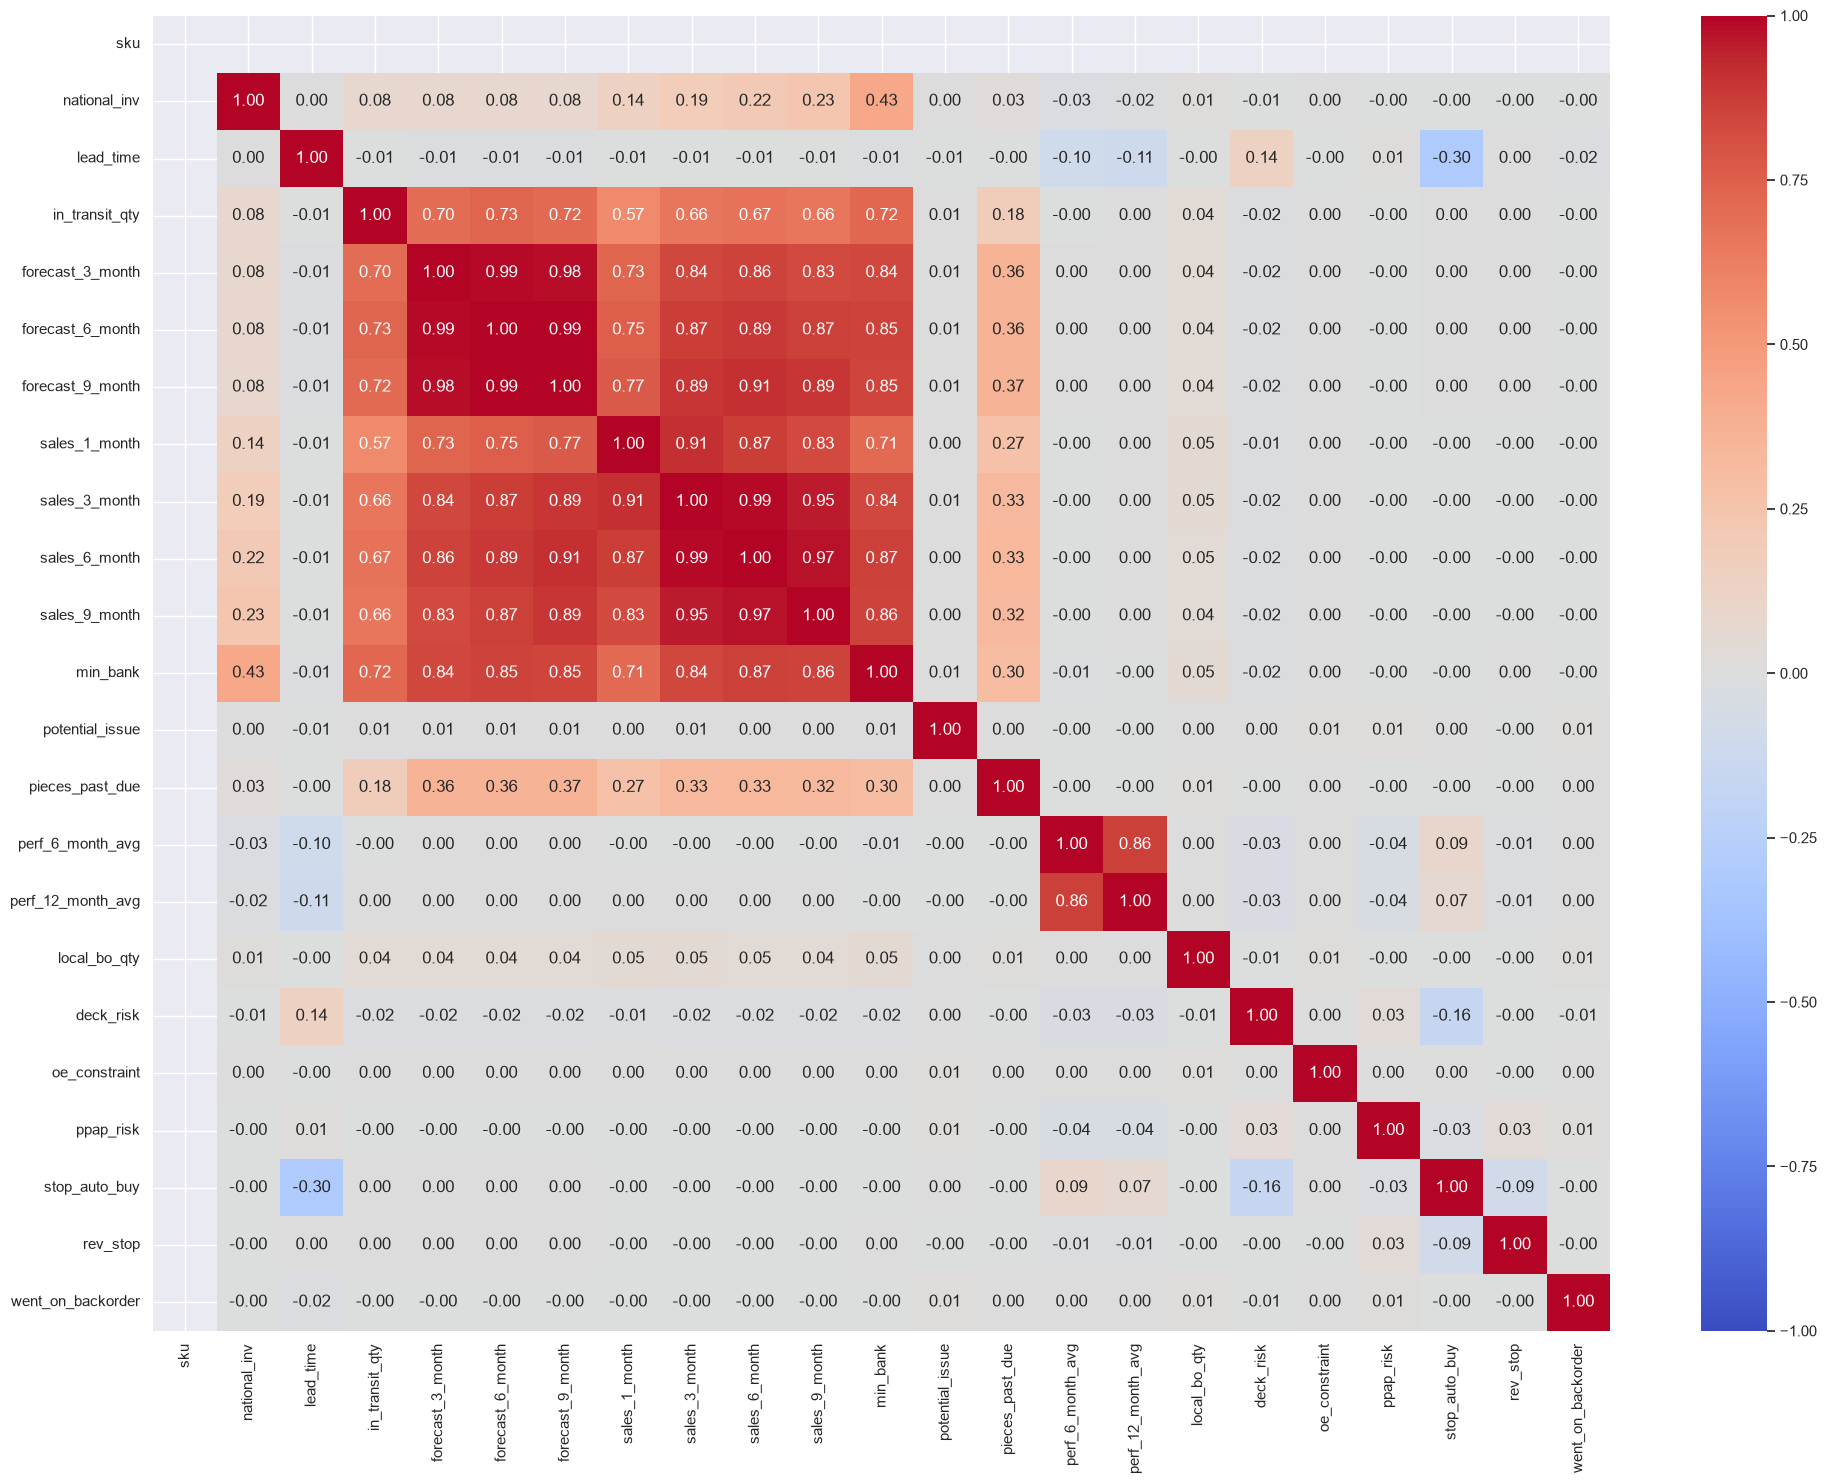

In [35]:
def convert_str_fields_to_int(
    df: pd.DataFrame,
    columns: list[str] | None = None,
    error_value: int = 0
) -> pd.DataFrame:
    df_copy = df.copy()
    cols = columns if columns is not None else df_copy.columns

    missing = set(cols) - set(df_copy.columns)
    if missing:
        raise ValueError(f"Colonnes introuvables dans le DataFrame : {missing}")

    mapping = {'Yes': 1, 'No': 0, 'yes': 1, 'no': 0}

    df_copy[cols] = (
        df_copy[cols]
        .apply(lambda col: col.map(mapping))
        .fillna(error_value)
        .astype(int)
    )

    return df_copy

cols_numeriques = trdf_clean.select_dtypes(exclude='number').columns.tolist()
trdf_for_corr = convert_str_fields_to_int(trdf_clean, columns=cols_numeriques)

matrixcorr = trdf_for_corr.corr()

plt.figure(figsize=(20, 15))
sns.heatmap(matrixcorr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.tight_layout()
plt.show()


10. Distribution de la valeur de sortie

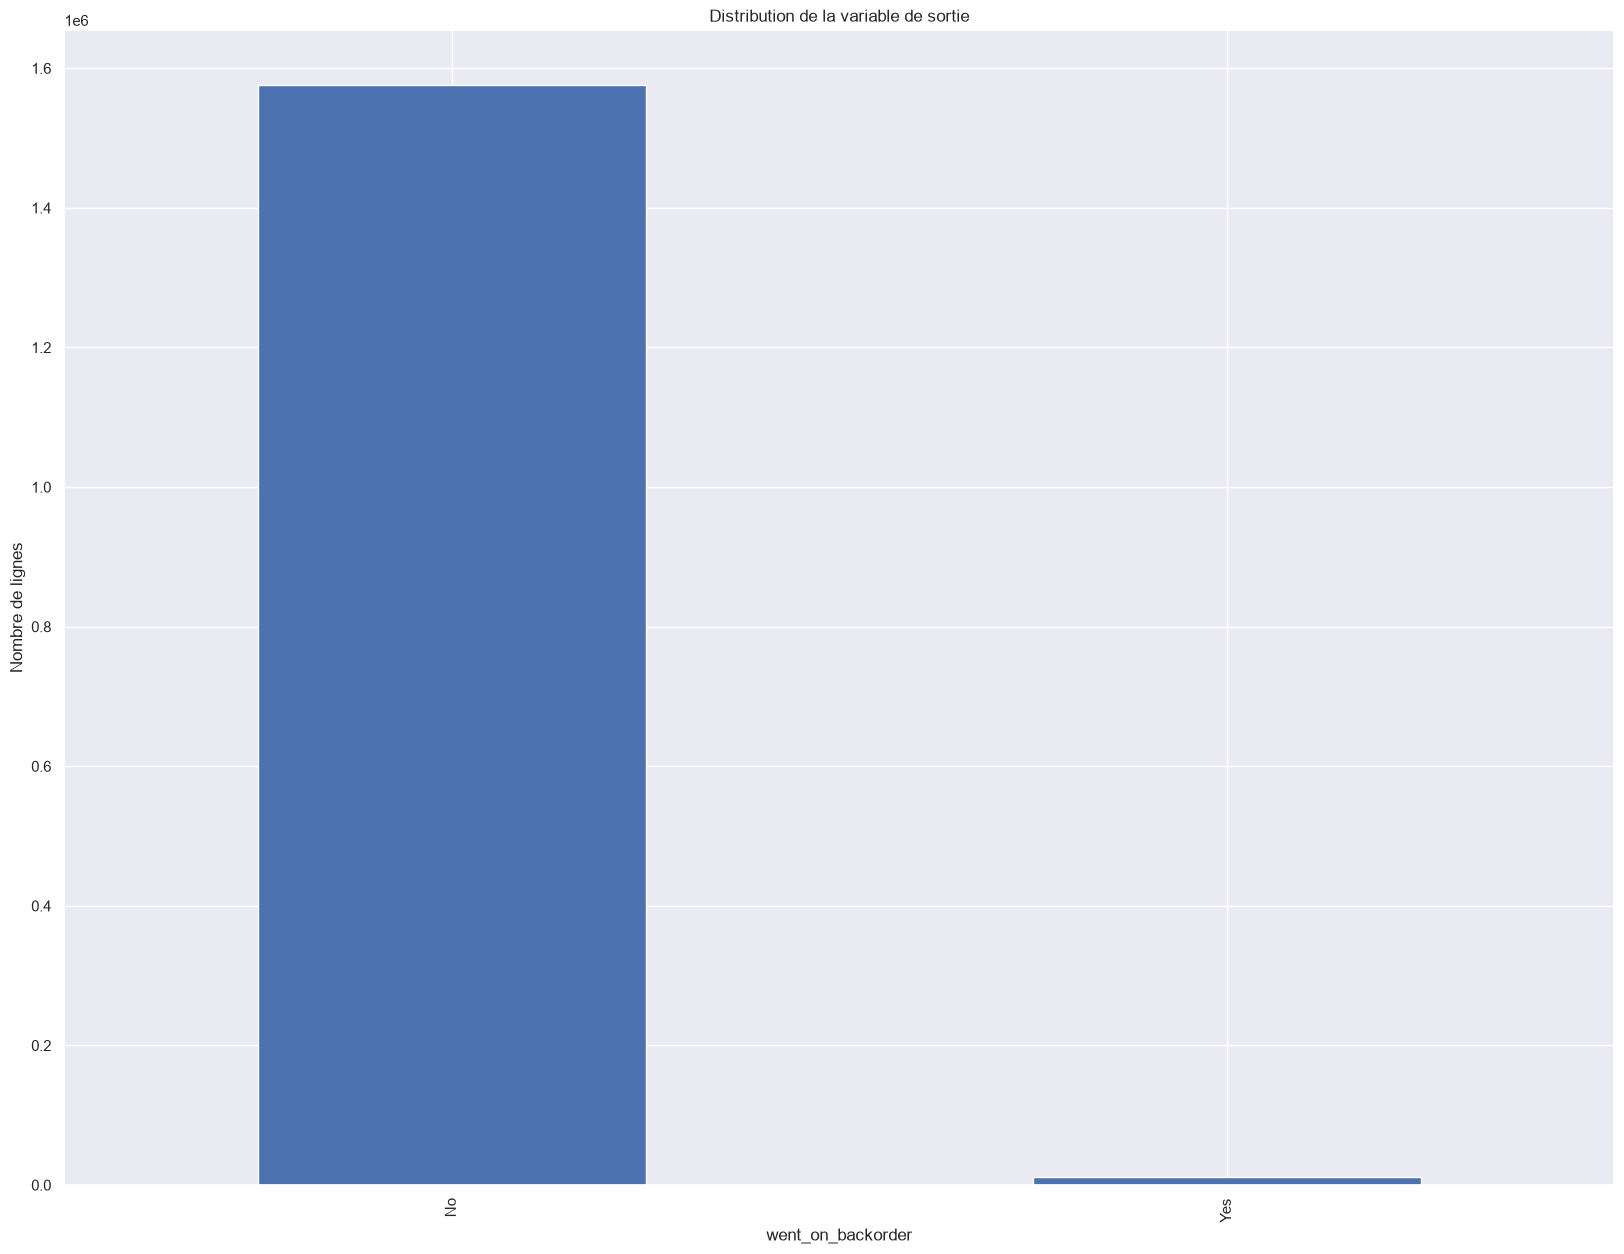

In [36]:
trdf_clean['went_on_backorder'].value_counts().plot(kind='bar')
plt.title('Distribution de la variable de sortie')
plt.xlabel('went_on_backorder')
plt.ylabel('Nombre de lignes')
plt.show()

La valeur de sortie est desiquilibree, le `No` est largement majoritaire

11. Surechantillonage

Methode 1: RandomOverSampler

In [37]:
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split

In [39]:
# Séparer les features X et la cible y
X = trdf_for_corr.drop(columns=['went_on_backorder'])
y = trdf_for_corr['went_on_backorder']

# Split train/test avant le suréchantillonnage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Appliquer l'oversampling uniquement sur le train
ros = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train)

print("Avant oversampling :", y_train.value_counts())
print("Après oversampling :", y_train_resampled.value_counts())

Avant oversampling : went_on_backorder
0    1260798
1       8775
Name: count, dtype: int64
Après oversampling : went_on_backorder
0    1260798
1    1260798
Name: count, dtype: int64


Methode 2: SMOTE

In [40]:
from imblearn.over_sampling import SMOTE

In [41]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Avant SMOTE :", y_train.value_counts())
print("Après SMOTE :", y_train_resampled.value_counts())

Avant SMOTE : went_on_backorder
0    1260798
1       8775
Name: count, dtype: int64
Après SMOTE : went_on_backorder
0    1260798
1    1260798
Name: count, dtype: int64


12. Affichage de la distribution

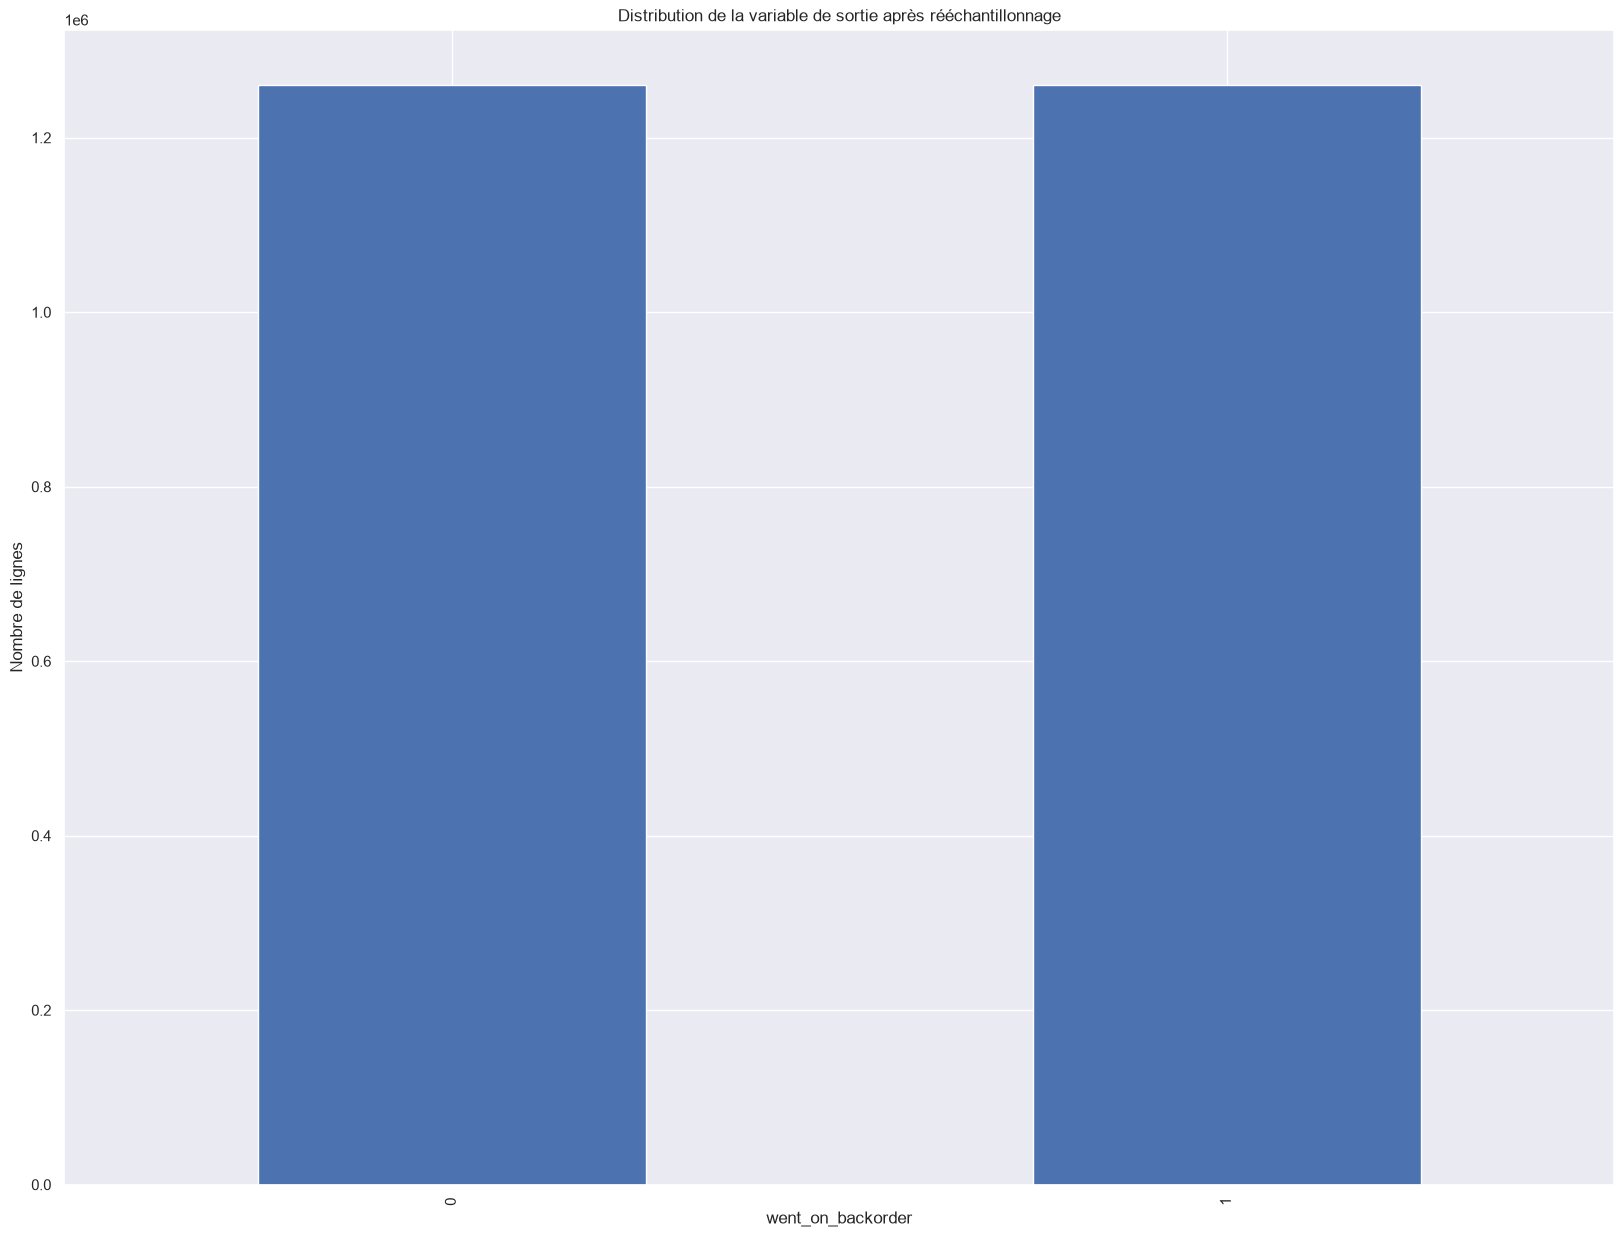

In [42]:
y_train_resampled.value_counts().plot(kind='bar')
plt.title('Distribution de la variable de sortie après rééchantillonnage')
plt.xlabel('went_on_backorder')
plt.ylabel('Nombre de lignes')
plt.show()